<a href="https://colab.research.google.com/github/shumrutha/240901104-python/blob/main/SKILL%20TEST%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Missing Values:
 Date           0
Temperature    0
Humidity       0
Wind Speed     0
Rainfall       0
dtype: int64

Monthly Average Temperature:
 Month
1    15.31
Name: Temperature, dtype: float64


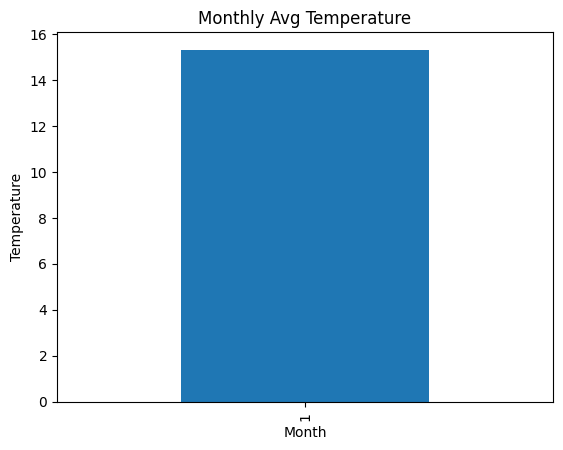

In [1]:
#1.
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Date': ['01-01-2025','02-01-2025','03-01-2025','04-01-2025','05-01-2025',
             '06-01-2025','07-01-2025','08-01-2025','09-01-2025','10-01-2025'],
    'Temperature': [15.2,16.8,14.5,13,17.6,18.1,16.2,12.4,13.8,15.5],
    'Humidity': [80,75,85,90,70,65,78,88,83,79],
    'Wind Speed': [10.5,8,12,15.2,7.4,6,9.1,14.3,11.5,10],
    'Rainfall': [0,0,1.2,5.4,0,0,0.5,2.1,0,0]
}

df = pd.DataFrame(data)

# Convert Date
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# a. Missing values
print("Missing Values:\n", df.isnull().sum())

# Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# b. Monthly average temperature
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['Temperature'].mean()

print("\nMonthly Average Temperature:\n", monthly_avg)

# c. Bar plot
plt.figure()
monthly_avg.plot(kind='bar')
plt.title("Monthly Avg Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

In [2]:
#2.
import pandas as pd

data = {
    'StudentID':[101,102,103,104,105,106,107,108,109,110],
    'Name':['Alice','Ben','Clara','David','Eva','Frank','Grace','Henry','Isla','Jack'],
    'Maths':[85,78,92,65,74,60,88,70,95,82],
    'Physics':[88,75,94,68,78,55,85,72,96,80],
    'Chemistry':[87,80,90,66,76,58,86,74,94,78]
}

df = pd.DataFrame(data)

# a. Summary statistics
print(df[['Maths','Physics','Chemistry']].describe())

# b. Average score
df['Average'] = df[['Maths','Physics','Chemistry']].mean(axis=1)
print("\nAverage Scores:\n", df[['Name','Average']])

# c. Students scoring <60 in more than 2 subjects
low = df[(df[['Maths','Physics','Chemistry']] < 60).sum(axis=1) > 2]
print("\nStudents below 60 in more than 2 subjects:\n", low[['Name']])

           Maths    Physics  Chemistry
count  10.000000  10.000000  10.000000
mean   78.900000  79.100000  78.900000
std    11.618472  12.449453  11.080012
min    60.000000  55.000000  58.000000
25%    71.000000  72.750000  74.500000
50%    80.000000  79.000000  79.000000
75%    87.250000  87.250000  86.750000
max    95.000000  96.000000  94.000000

Average Scores:
     Name    Average
0  Alice  86.666667
1    Ben  77.666667
2  Clara  92.000000
3  David  66.333333
4    Eva  76.000000
5  Frank  57.666667
6  Grace  86.333333
7  Henry  72.000000
8   Isla  95.000000
9   Jack  80.000000

Students below 60 in more than 2 subjects:
 Empty DataFrame
Columns: [Name]
Index: []


count     8.000000
mean      7.500000
std      12.247449
min     -10.000000
25%      -1.250000
50%       7.500000
75%      16.250000
max      25.000000
Name: DepartureDelay, dtype: float64

Average Delay per Airline:
 Airline
A    11.666667
B    11.666667
C    -5.000000
Name: DepartureDelay, dtype: float64

Most Common Origin:
 LA

Most Common Destination:
 NY


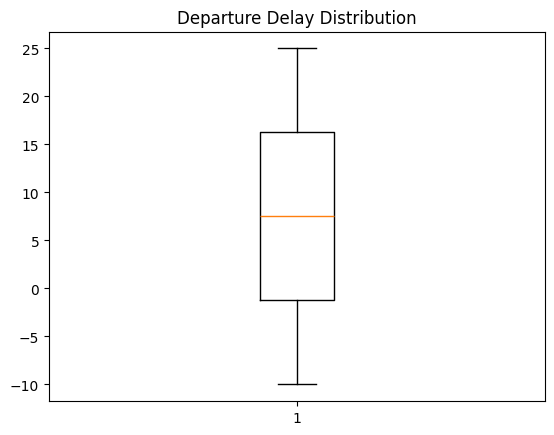

In [3]:
#3.
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Airline':['A','B','A','C','B','A','C','B'],
    'Origin':['NY','LA','NY','SF','LA','NY','SF','LA'],
    'Destination':['LA','NY','SF','NY','SF','LA','NY','SF'],
    'DepartureDelay':[10,-5,20,0,15,5,-10,25]
}

df = pd.DataFrame(data)

# a. Summary statistics
print(df['DepartureDelay'].describe())

# b. Average delay per airline
print("\nAverage Delay per Airline:\n", df.groupby('Airline')['DepartureDelay'].mean())

# c. Most common origin & destination
print("\nMost Common Origin:\n", df['Origin'].mode()[0])
print("\nMost Common Destination:\n", df['Destination'].mode()[0])

# d. Box plot
plt.figure()
plt.boxplot(df['DepartureDelay'])
plt.title("Departure Delay Distribution")
plt.show()

In [4]:
#4.
import numpy as np

# Points
p1 = np.array([2,3])
p2 = np.array([5,7])

# Euclidean distance
distance = np.sqrt(np.sum((p1 - p2)**2))
print("Euclidean Distance:", distance)

# Dot product (matrix)
A = np.array([[1,2],[3,4]])
B = np.array([[5,6],[7,8]])

result = np.dot(A,B)
print("\nDot Product:\n", result)

Euclidean Distance: 5.0

Dot Product:
 [[19 22]
 [43 50]]


       Temperature
count   365.000000
mean     24.950260
std       5.185770
min       8.703188
25%      21.383059
50%      25.044213
75%      28.454696
max      37.154854


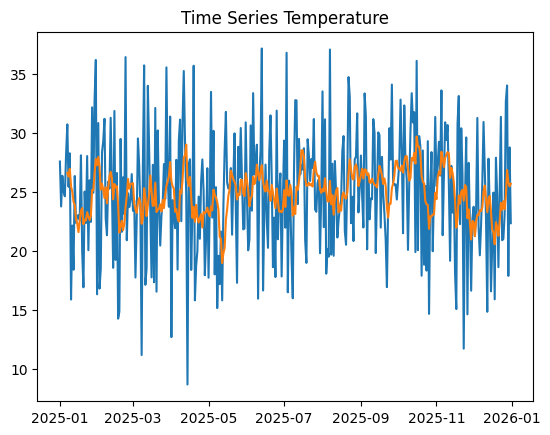

In [5]:
#5.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dates = pd.date_range(start='2025-01-01', periods=365)
temps = np.random.normal(25,5,365)

df = pd.DataFrame({'Date':dates,'Temperature':temps})
df.set_index('Date', inplace=True)

print(df.describe())

# Rolling mean
df['Rolling'] = df['Temperature'].rolling(7).mean()

# Plot
plt.figure()
plt.plot(df['Temperature'])
plt.plot(df['Rolling'])
plt.title("Time Series Temperature")
plt.show()

Mean: 108.19300209862213
Max: 120.58503557621646


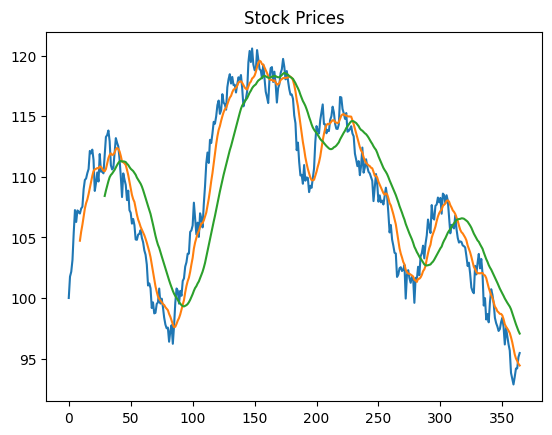

In [6]:
#6.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

prices = [100]

for i in range(1,365):
    change = np.random.normal(0,1)
    prices.append(prices[-1] + change)

df = pd.DataFrame({'Price':prices})

# Moving averages
df['MA10'] = df['Price'].rolling(10).mean()
df['MA30'] = df['Price'].rolling(30).mean()

# Metrics
print("Mean:", df['Price'].mean())
print("Max:", df['Price'].max())

# Plot
plt.figure()
plt.plot(df['Price'])
plt.plot(df['MA10'])
plt.plot(df['MA30'])
plt.title("Stock Prices")
plt.show()

In [7]:
#7.
import pandas as pd

# a. Create DataFrame
data = ['Apple','Banana','Cherry','Mango']
prices = [120,40,150,100]

fruits_df = pd.DataFrame(list(zip(data,prices)), columns=['Fruit','Price'])

# b. Info
print("\nInfo:")
fruits_df.info()

# c. Print full DataFrame
print("\nFull DataFrame:")
print(fruits_df.to_string())

# d. Statistics
print("\nStatistics:")
print(fruits_df['Price'].describe())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Fruit   4 non-null      object
 1   Price   4 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 196.0+ bytes

Full DataFrame:
    Fruit  Price
0   Apple    120
1  Banana     40
2  Cherry    150
3   Mango    100

Statistics:
count      4.000000
mean     102.500000
std       46.457866
min       40.000000
25%       85.000000
50%      110.000000
75%      127.500000
max      150.000000
Name: Price, dtype: float64
